In [53]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd

noisy_path = "data/noisy/32.wav"
denoised_path = "data/denoised/32.wav"
clean_path = "data/clean/32.wav"



In [54]:
def show_spectrogram(noisy_path, denoised_path, clean_path):
    audio_noisy, sr = librosa.load(noisy_path, sr=44100)
    audio_denoised, _ = librosa.load(denoised_path, sr=44100)
    audio_clean, _ = librosa.load(clean_path, sr=44100)

    S_noise = librosa.amplitude_to_db(np.abs(librosa.stft(audio_noisy)), ref=np.max)
    S_denoise = librosa.amplitude_to_db(np.abs(librosa.stft(audio_denoised)), ref=np.max)
    S_clean = librosa.amplitude_to_db(np.abs(librosa.stft(audio_clean)), ref=np.max)
    
    plt.figure(figsize=(18, 12))
    
    titles = ['Noisy Input', 'Model', 'Ground Truth']
    specs = [S_noise, S_denoise, S_clean]
    
    for i, (spec, title) in enumerate(zip(specs, titles)):
        plt.subplot(3, 1, i+1)
        librosa.display.specshow(spec, sr=sr, x_axis='time', y_axis='hz', cmap='magma')
        plt.title(title)
        plt.colorbar(format='%+2.0f dB')
    plt.legend()
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_1462/132463118.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_1462/132463118.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


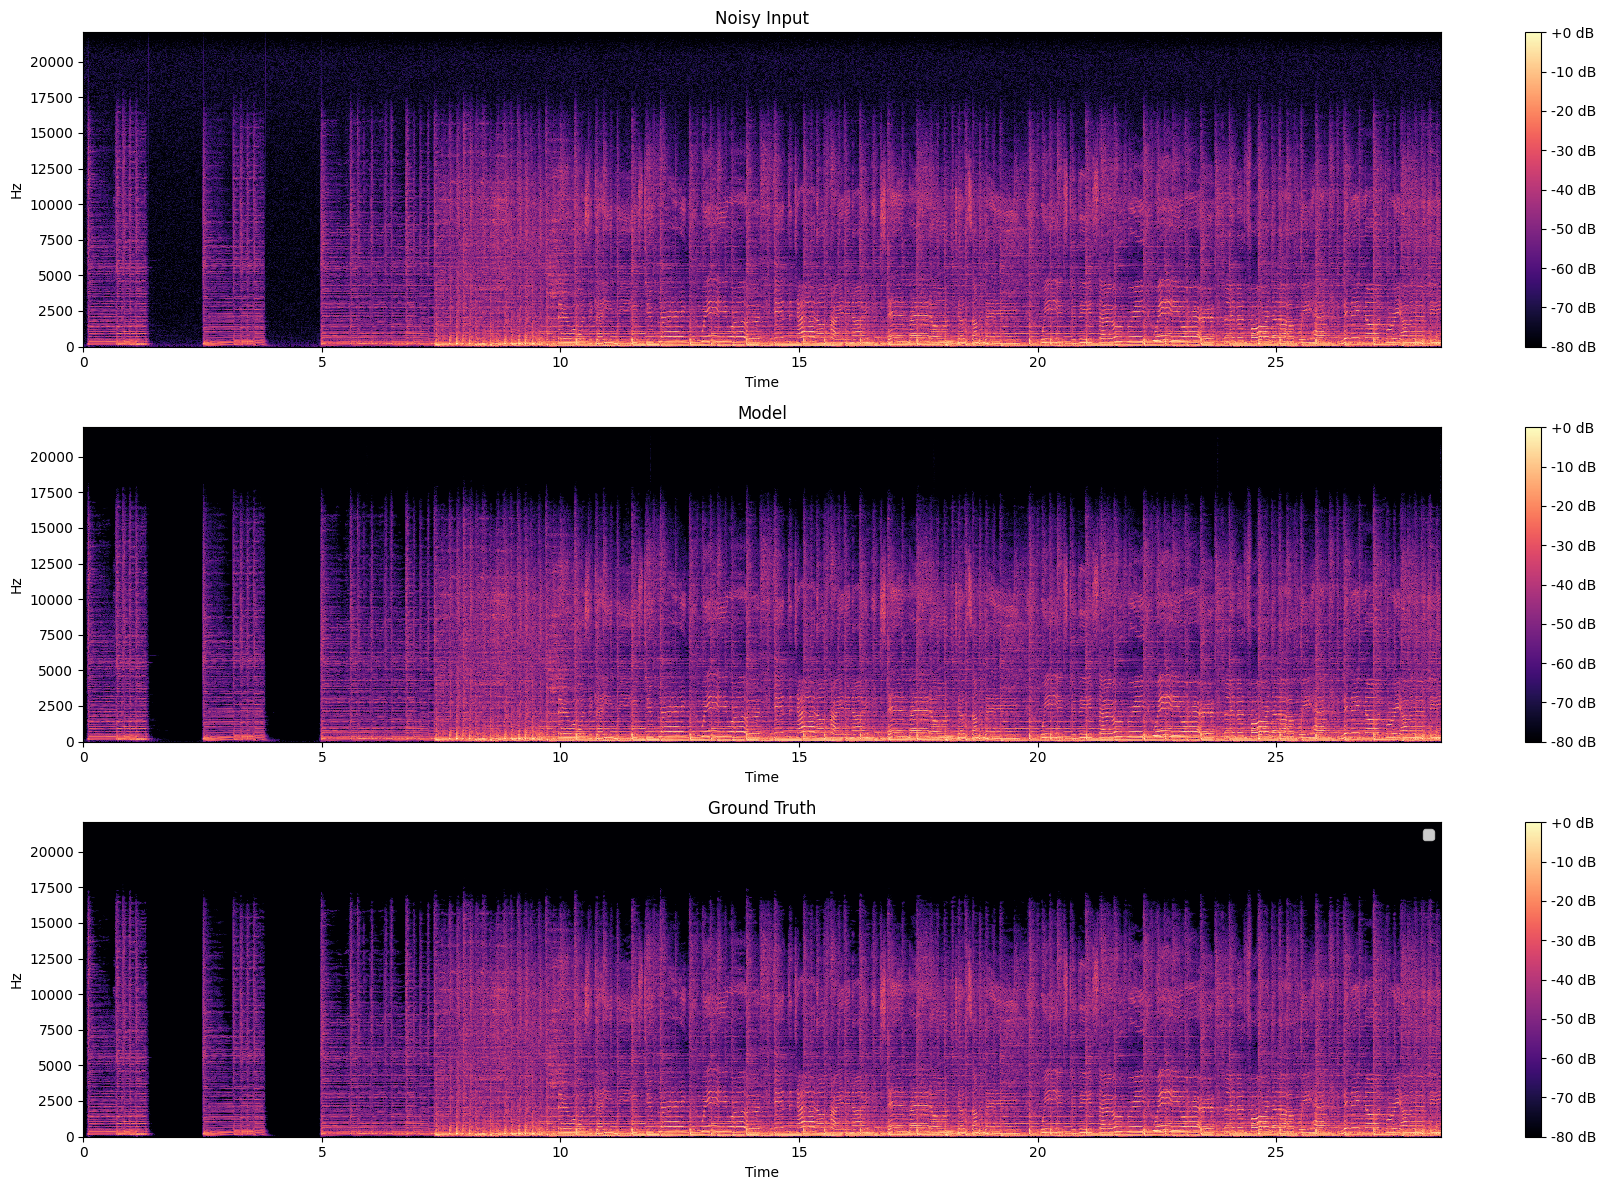

In [55]:
show_spectrogram(noisy_path, denoised_path, clean_path)